In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
df = pd.read_csv("../data/time_series_60min_singleindex.csv",
                 index_col=0, parse_dates=True)

# Keep only German columns
de_cols = ['DE_load_actual_entsoe_transparency', 'DE_solar_generation_actual', 'DE_wind_onshore_generation_actual', 'DE_wind_offshore_generation_actual', 'DE_LU_price_day_ahead']
## de_cols = [c for c in df.columns if c.startswith("DE_")]
de = df[de_cols]
de.columns.tolist()

['DE_load_actual_entsoe_transparency',
 'DE_solar_generation_actual',
 'DE_wind_onshore_generation_actual',
 'DE_wind_offshore_generation_actual',
 'DE_LU_price_day_ahead']

In [15]:
# Keep only columns that contain "DE_"
# df = df.filter(regex="DE_").head()

<Axes: xlabel='utc_timestamp'>

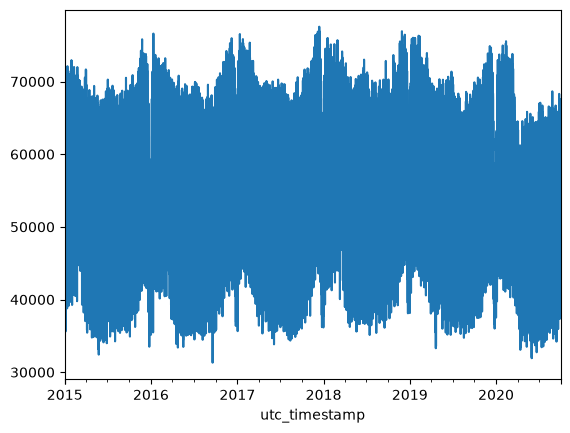

In [16]:
# What does German load look like?
de['DE_load_actual_entsoe_transparency'].plot()

<Axes: xlabel='utc_timestamp'>

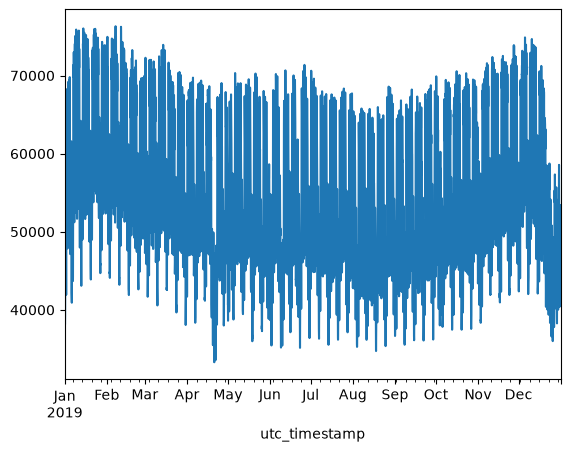

In [17]:
# Zoom on the year 2019
de['DE_load_actual_entsoe_transparency'].loc['2019'].plot()

<Axes: xlabel='utc_timestamp'>

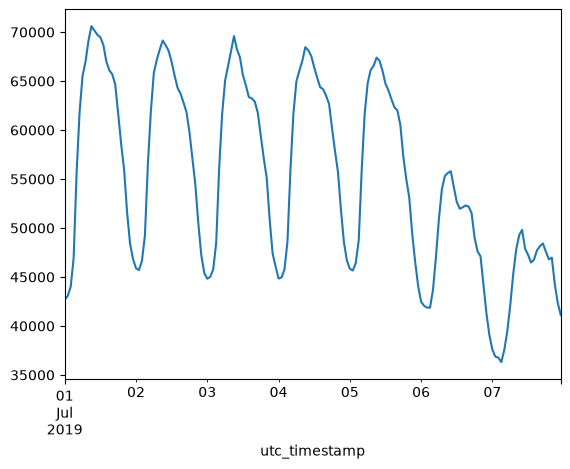

In [18]:
# A summer week in 2019
de['DE_load_actual_entsoe_transparency'].loc['2019-07-01':'2019-07-07'].plot()

<Axes: xlabel='utc_timestamp'>

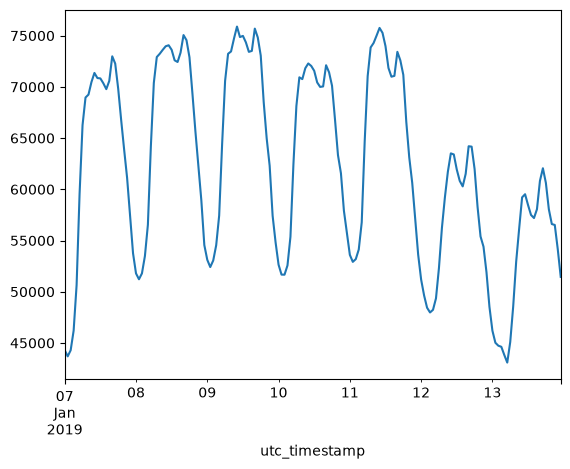

In [21]:
# A winter week in 2019
de['DE_load_actual_entsoe_transparency'].loc['2019-01-07':'2019-01-13'].plot()

Observations:
1. the daily double-peak
2. the weekday/weekend gap
3. seasonal level differences

<Axes: xlabel='utc_timestamp'>

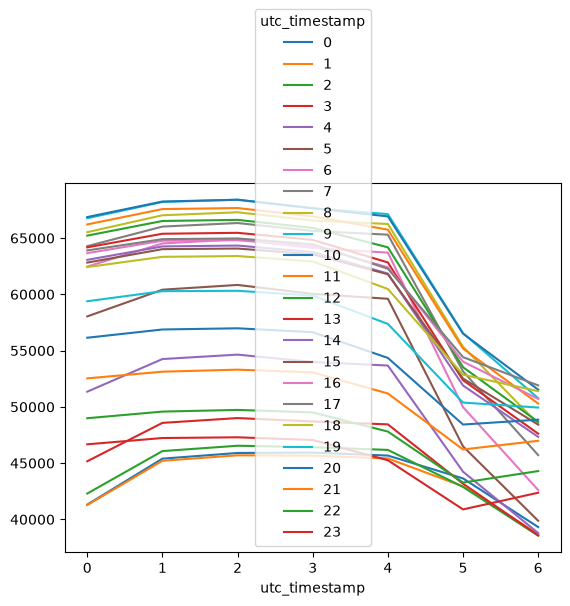

In [22]:
# average load by hour-of-day, grouped by weekday vs. weekend
de['DE_load_actual_entsoe_transparency'].groupby([de.index.weekday, de.index.hour]).mean().unstack(level=1).plot()

<Axes: xlabel='utc_timestamp'>

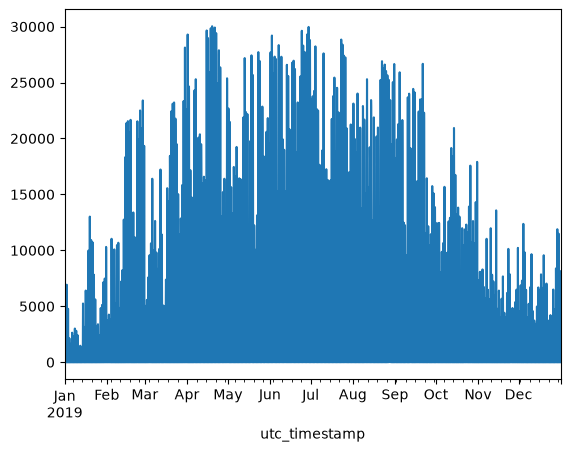

In [25]:
# What did solar look like in 2019?
de['DE_solar_generation_actual'].loc['2019'].plot()

<Axes: xlabel='utc_timestamp'>

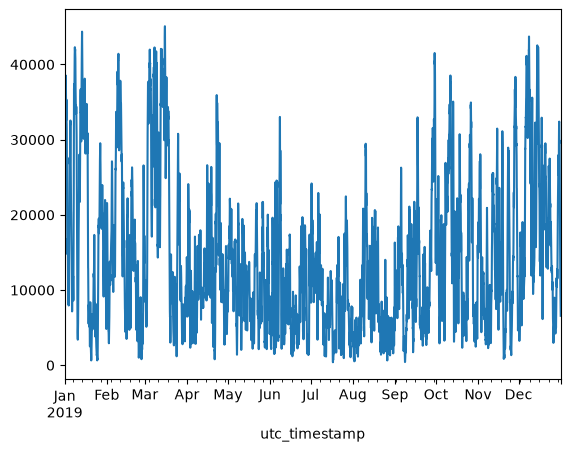

In [26]:
# What did total wind look like in 2019?
de['DE_wind_total'] = de['DE_wind_onshore_generation_actual'] + de['DE_wind_offshore_generation_actual']    
de['DE_wind_total'].loc['2019'].plot()

wind and solar are almost negatives of each other.
And this is the reason why negative prices cluster on sunny spring weekends but also occur on stormy winter nights.

In [27]:
# Residual Load

de["residual_load"] = (de["DE_load_actual_entsoe_transparency"]
    - de["DE_solar_generation_actual"]
    - de["DE_wind_onshore_generation_actual"]
    - de["DE_wind_offshore_generation_actual"].fillna(0))

<Axes: xlabel='utc_timestamp'>

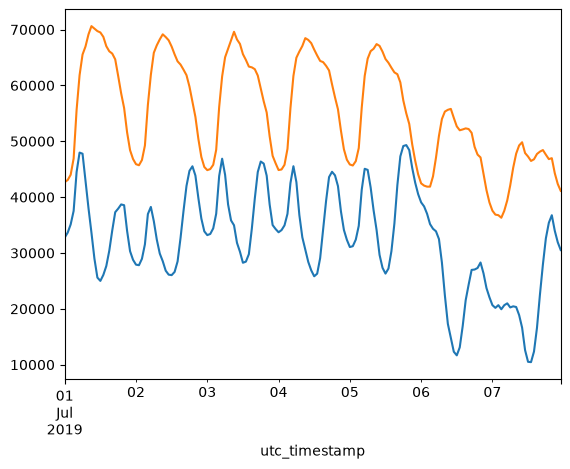

In [30]:
# Plot residual load against raw load for the same summer week
de['residual_load'].loc['2019-07-01':'2019-07-07'].plot(label='Residual Load')
de['DE_load_actual_entsoe_transparency'].loc['2019-07-01':'2019-07-07'].plot(label='Raw Load')

duck curve

<Axes: xlabel='residual_load', ylabel='DE_LU_price_day_ahead'>

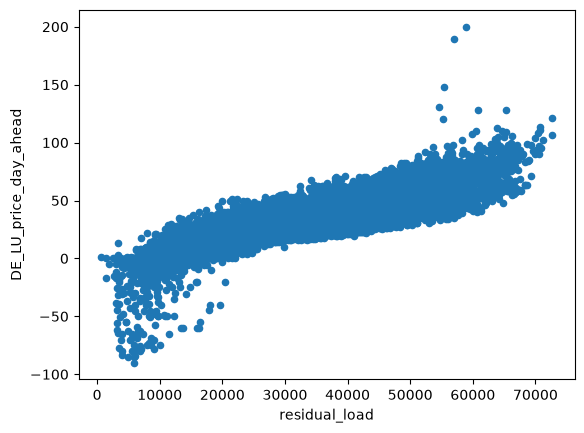

In [32]:
# scatter residual load (x) vs. day-ahead price (y)
de.plot(x='residual_load', y='DE_LU_price_day_ahead', kind='scatter')

# Summary
The merit order is made visible in data — an upward-sloping cloud, steepening at high residual load (expensive peakers), scattering into negative prices at very low residual load. 